Diffusion: 100 samples
Photoactive: 100 samples


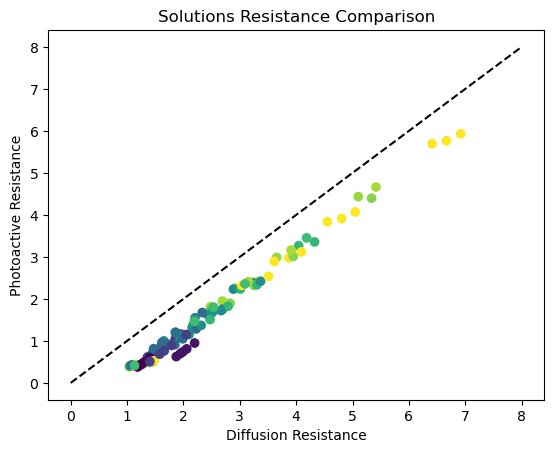

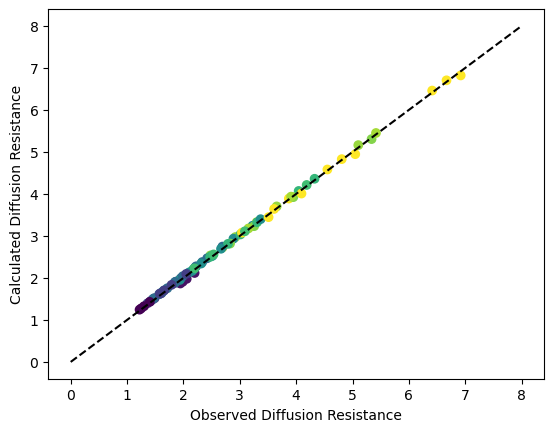

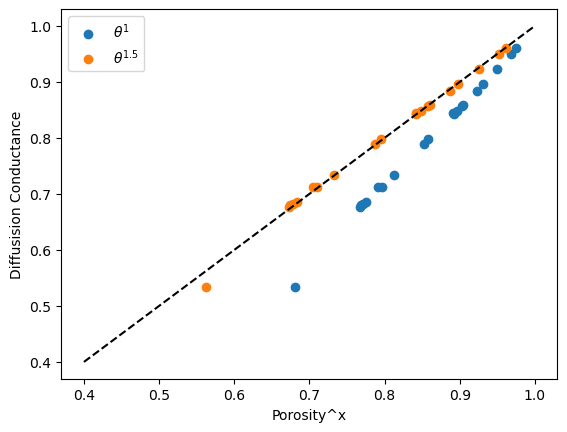

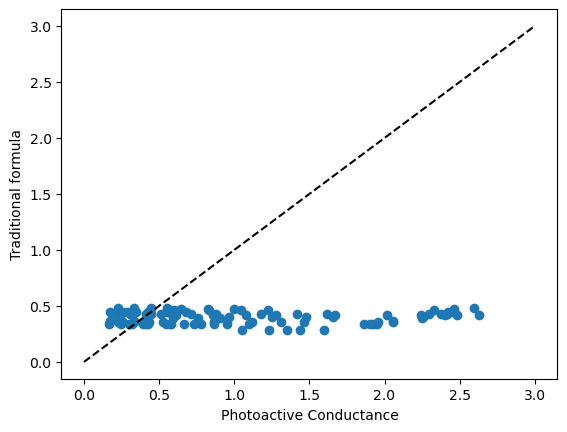

In [26]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd  
from mscthesis.core.io import load_dataframe 
from mscthesis.config import ProjectConfig 
from mscthesis.paths import ProjectPaths

config = ProjectConfig()
paths = ProjectPaths(config.behavior.storage_root)
df = load_dataframe(paths.solutions_index.require())

df.head()

df_diff = df[(df["solver"] == "diffusion")]
df_photo = df[(df["solver"] == "photoactive")]

print(f"Diffusion: {len(df_diff)} samples")
print(f"Photoactive: {len(df_photo)} samples")

plt.scatter(df_diff["resistance"], df_photo["resistance"].values, c=df_diff["plug_aspect"], cmap="viridis")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Diffusion Resistance")
plt.ylabel("Photoactive Resistance")
plt.title("Solutions Resistance Comparison")
plt.show()

resistance_calculated = 1/df_diff["porosity"].values**1.5 + 3/4 * df_diff["plug_aspect"].values * (df_diff["plug_aspect"].values/df_diff["stomatal_aspect"].values - 1)

plt.scatter(df_diff["resistance"], resistance_calculated, c=df_diff["plug_aspect"], cmap="viridis")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Observed Diffusion Resistance")
plt.ylabel("Calculated Diffusion Resistance")
plt.show()

df_diff_porous = df_diff[df_diff["specifier"] == 0]
plt.scatter(df_diff_porous["porosity"], 1/df_diff_porous["resistance"], label=r"$\theta^{1}$")
plt.scatter(df_diff_porous["porosity"]**1.5, 1/df_diff_porous["resistance"], label=r"$\theta^{1.5}$")
plt.plot([0.4, 1], [0.4, 1], "k--")
plt.xlabel("Porosity^x")
plt.ylabel("Diffusision Conductance")
plt.legend()
plt.show()

plt.scatter(1/df_photo["resistance"], 0.5 * df_photo["porosity"]**1.5)
plt.plot([0, 3], [0, 3], "k--")
plt.xlabel("Photoactive Conductance")
plt.ylabel("Traditional formula")
plt.show()
